# CardioIA – Fase 2 | Ir Além 2: diagnóstico visual de ECG com rede neural MLP

Este notebook treina uma rede neural do tipo **MLP (Perceptron Multicamadas)** com Keras para classificar **imagens de eletrocardiograma** em **normal** ou **anormal**.

**Por que PTB-XL e não o dataset sugerido no enunciado?** O dataset do Kaggle (`shayanfazeli/heartbeat`) não tem imagens: são arquivos CSV com 187 valores numéricos por batimento. Como a atividade pede classificação de *imagens*, reaproveitamos o pipeline da **Fase 1**, que gera imagens de ECG a partir do **PTB-XL** (PhysioNet, acesso aberto e sem login), com três ajustes:

1. **Sem título, eixos e grade.** Na Fase 1 o título de cada imagem trazia o nome da classe (`Classe NORM`). Se isso ficasse, a rede poderia "ler" a resposta escrita na imagem em vez de aprender o traçado. Isso se chama *vazamento de rótulo*.
2. **Mesma escala em todas as imagens**, para preservar a amplitude do sinal (explicado na seção 3).
3. **Mais imagens e classes equilibradas.** Em vez de 100 imagens, geramos 600 normais e 600 anormais.
4. **Separação por paciente.** O PTB-XL traz a coluna `strat_fold`, que garante que o mesmo paciente não apareça ao mesmo tempo no treino e no teste.

> Projeto acadêmico. O modelo não deve ser usado para decisões clínicas.
>
> No Google Colab, rode `!pip install wfdb` antes da primeira célula.

In [1]:
import ast
import os
import shutil
import urllib.request
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
import wfdb
from PIL import Image
import keras
from keras import layers
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

keras.utils.set_random_seed(42)

## 1. Metadados do PTB-XL e definição das classes

Mesmo código da Fase 1: baixamos a tabela de exames e a tabela de códigos diagnósticos e agrupamos cada exame nas superclasses **NORM, MI, STTC, CD e HYP**.

Para o problema binário:

- **normal:** exames cuja única superclasse é NORM;
- **anormal:** exames com pelo menos uma das superclasses MI (infarto), STTC (alteração ST/T), CD (distúrbio de condução) ou HYP (hipertrofia), e sem NORM;
- exames sem diagnóstico ou com classes misturadas ficam de fora.

In [2]:
BASE_URL = "https://physionet.org/files/ptb-xl/1.0.3/"
os.makedirs("dados", exist_ok=True)

for arquivo in ["ptbxl_database.csv", "scp_statements.csv"]:
    if not os.path.exists(f"dados/{arquivo}"):
        urllib.request.urlretrieve(BASE_URL + arquivo, f"dados/{arquivo}")

df = pd.read_csv("dados/ptbxl_database.csv", index_col="ecg_id")
scp = pd.read_csv("dados/scp_statements.csv", index_col=0)
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)
diagnosticos = scp[scp["diagnostic"] == 1]


def identificar_superclasses(scp_codes):
    return {diagnosticos.loc[codigo, "diagnostic_class"] for codigo in scp_codes if codigo in diagnosticos.index}


def rotular(superclasses):
    if superclasses == {"NORM"}:
        return "normal"
    if superclasses and "NORM" not in superclasses:
        return "anormal"
    return None


df["superclasses"] = df["scp_codes"].apply(identificar_superclasses)
df["classe"] = df["superclasses"].apply(rotular)
df["classe"].value_counts()

classe
anormal    11874
normal      9069
Name: count, dtype: int64

## 2. Amostra equilibrada

A base completa tem mais de 20 mil exames. Para o notebook rodar em poucos minutos, sorteamos 600 exames de cada classe. Também olhamos idade e sexo de cada grupo, porque diferenças aqui podem virar **viés**: a rede pode aprender "ECG de pessoa mais velha" em vez de "ECG anormal".

In [3]:
POR_CLASSE = 600

amostra = df.dropna(subset=["classe"]).groupby("classe").sample(POR_CLASSE, random_state=42)

amostra.groupby("classe").agg(
    exames=("age", "size"),
    idade_media=("age", "mean"),
    percentual_mulheres=("sex", lambda sexo: f"{sexo.mean():.0%}"),
).round(1)

,exames,idade_media,percentual_mulheres
classe,,,
anormal,600,69.3,41%
normal,600,54.2,53%


## 3. Geração das imagens

Cada exame tem 12 derivações de 10 segundos, amostradas a 100 Hz. Como na Fase 1, as 12 derivações são desenhadas empilhadas em uma única imagem PNG, agora sem título, eixos ou grade. Duas decisões fizeram diferença:

- **Escala vertical fixa** (`set_ylim`): o Matplotlib ajusta a escala de cada imagem automaticamente, e isso apaga a informação de **amplitude**. Um QRS muito alto, típico de hipertrofia (HYP), ficaria do mesmo tamanho de um QRS normal. Com a mesma escala em todas as imagens, 1 mV ocupa sempre a mesma altura, como no papel milimetrado de um ECG de verdade.
- **Centralização de cada derivação pela mediana:** remove o deslocamento da linha de base, para que as derivações não invadam a vizinha nem saiam da imagem.

Com a mesma rede e o mesmo treino, as imagens com escala automática (como na Fase 1) chegaram a cerca de 65% de acurácia no teste, contra cerca de 71% com escala fixa (média de 5 execuções).

Os sinais são baixados direto do PhysioNet pelo `wfdb`, em paralelo, e as imagens que já existem não são geradas de novo.

In [4]:
for classe in ["normal", "anormal"]:
    os.makedirs(f"dados/imagens/{classe}", exist_ok=True)


def gerar_imagem(ecg_id):
    registro = amostra.loc[ecg_id]
    destino = f"dados/imagens/{registro['classe']}/{ecg_id}.png"
    if os.path.exists(destino):
        return destino

    pasta, nome = registro["filename_lr"].rsplit("/", 1)
    sinal, _ = wfdb.rdsamp(nome, pn_dir=f"ptb-xl/1.0.3/{pasta}")
    sinal = sinal - np.median(sinal, axis=0)

    figura = Figure(figsize=(10, 8), dpi=50)
    eixo = figura.subplots()
    figura.subplots_adjust(0, 0, 1, 1)
    for derivacao in range(12):
        eixo.plot(sinal[:, derivacao] + derivacao * 2, linewidth=1)
    eixo.set_xlim(0, len(sinal))
    eixo.set_ylim(-2, 24)
    eixo.axis("off")
    figura.savefig(destino)
    return destino


with ThreadPoolExecutor(max_workers=16) as executor:
    amostra["imagem"] = list(executor.map(gerar_imagem, amostra.index))

print(f"{len(amostra)} imagens prontas em dados/imagens/")

1200 imagens prontas em dados/imagens/


Alguns exemplos também são copiados para a pasta `exemplos/` do repositório:

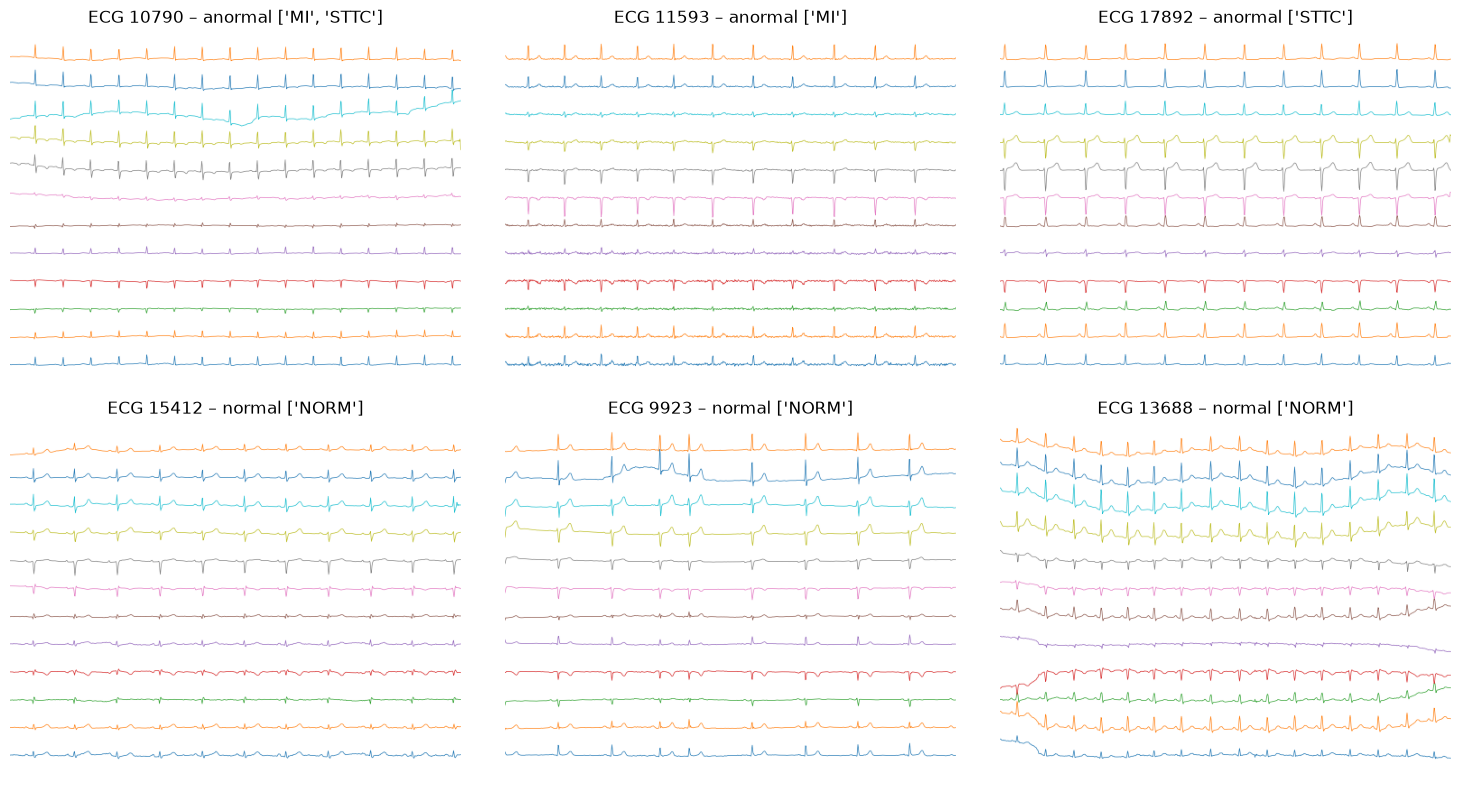

In [5]:
os.makedirs("exemplos", exist_ok=True)
exemplos = amostra.groupby("classe").head(3)

fig, eixos = plt.subplots(2, 3, figsize=(15, 8))
for eixo, (ecg_id, registro) in zip(eixos.ravel(), exemplos.iterrows()):
    shutil.copy(registro["imagem"], f"exemplos/{registro['classe']}_{ecg_id}.png")
    eixo.imshow(Image.open(registro["imagem"]))
    eixo.set_title(f"ECG {ecg_id} – {registro['classe']} {sorted(registro['superclasses'])}")
    eixo.axis("off")
plt.tight_layout()
plt.show()

## 4. Pré-processamento

Uma MLP recebe um vetor de números, não uma imagem. Por isso cada imagem passa por quatro passos:

1. **Tons de cinza:** as cores das derivações não carregam informação diagnóstica, então 3 canais (RGB) viram 1.
2. **Redimensionamento** para 128 × 128 pixels, para que todas as imagens tenham o mesmo tamanho e a rede fique menor.
3. **Normalização e inversão:** os valores vão de 0–255 para 0–1 e são invertidos, de modo que o fundo branco vire 0 e o traçado vire valores próximos de 1.
4. **Achatamento:** a matriz 128 × 128 vira um vetor de 16.384 posições, a entrada da MLP.

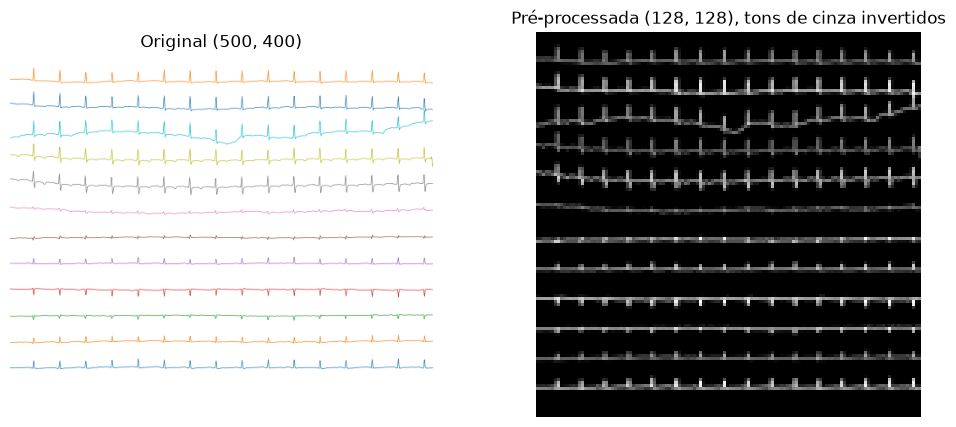

Formato de X: (1200, 16384)


In [6]:
TAMANHO = (128, 128)


def preprocessar(caminho):
    imagem = Image.open(caminho).convert("L").resize(TAMANHO)
    return 1 - np.asarray(imagem, dtype="float32") / 255


exemplo = amostra["imagem"].iloc[0]
fig, eixos = plt.subplots(1, 2, figsize=(12, 5))
eixos[0].imshow(Image.open(exemplo))
eixos[0].set_title(f"Original {Image.open(exemplo).size}")
eixos[1].imshow(preprocessar(exemplo), cmap="gray")
eixos[1].set_title(f"Pré-processada {TAMANHO}, tons de cinza invertidos")
for eixo in eixos:
    eixo.axis("off")
plt.show()

X = np.stack([preprocessar(caminho).reshape(-1) for caminho in amostra["imagem"]])
y = (amostra["classe"] == "anormal").astype(int).to_numpy()
print("Formato de X:", X.shape)

## 5. Treino, validação e teste

Usamos os *folds* oficiais do PTB-XL: 1 a 8 para treino, 9 para validação (acompanhar o treino e parar na hora certa) e 10 para teste (avaliação final, dados que a rede nunca viu).

In [7]:
fold = amostra["strat_fold"].to_numpy()
treino, validacao, teste = fold <= 8, fold == 9, fold == 10

for nome, filtro in [("Treino", treino), ("Validação", validacao), ("Teste", teste)]:
    print(f"{nome:10} {filtro.sum():4} imagens | anormais: {y[filtro].mean():.0%}")

Treino      948 imagens | anormais: 50%
Validação   130 imagens | anormais: 50%
Teste       122 imagens | anormais: 48%


## 6. Rede neural MLP

- **Entrada:** 16.384 pixels.
- **Duas camadas ocultas** (`Dense`) com 256 e 64 neurônios e ativação ReLU.
- **Dropout de 50%** depois de cada camada oculta: desliga metade dos neurônios, sorteados a cada passo do treino, para reduzir o *overfitting* (decorar o treino).
- **Saída:** 1 neurônio com ativação sigmoide, que devolve a probabilidade de o ECG ser anormal.
- **Perda:** entropia cruzada binária. **Otimizador:** Adam com taxa de aprendizado de 0,00003.

**Por que uma taxa de aprendizado tão baixa?** Com o padrão do Adam (0,001), a rede decorava o treino em 2 ou 3 épocas, e a acurácia no teste variava entre 64% e 73% dependendo só da semente aleatória. Com 0,00003 o aprendizado é mais lento e estável: em testes com 5 sementes diferentes, a acurácia ficou em torno de 70%, com variação menor que 1 ponto.

In [8]:
modelo = keras.Sequential([
    keras.Input(shape=(X.shape[1],)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])
modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=3e-5), loss="binary_crossentropy", metrics=["accuracy"])
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,211,073 (16.06 MB)

 Trainable params: 4,211,073 (16.06 MB)

 Non-trainable params: 0 (0.00 B)

O treino para sozinho (`EarlyStopping`) quando a perda na validação deixa de melhorar por 10 épocas seguidas, e os melhores pesos são recuperados.

In [9]:
historico = modelo.fit(
    X[treino], y[treino],
    validation_data=(X[validacao], y[validacao]),
    epochs=100,
    batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=2,
)

Epoch 1/100


30/30 - 2s - 57ms/step - accuracy: 0.5380 - loss: 0.6891 - val_accuracy: 0.6231 - val_loss: 0.6854


Epoch 2/100


30/30 - 0s - 13ms/step - accuracy: 0.5686 - loss: 0.6811 - val_accuracy: 0.6538 - val_loss: 0.6768


Epoch 3/100


...

30/30 - 1s - 38ms/step - accuracy: 0.8850 - loss: 0.3273 - val_accuracy: 0.7077 - val_loss: 0.5678


Epoch 35/100


30/30 - 1s - 38ms/step - accuracy: 0.8924 - loss: 0.3297 - val_accuracy: 0.7000 - val_loss: 0.5687


Epoch 36/100


30/30 - 1s - 40ms/step - accuracy: 0.9030 - loss: 0.3049 - val_accuracy: 0.7000 - val_loss: 0.5703


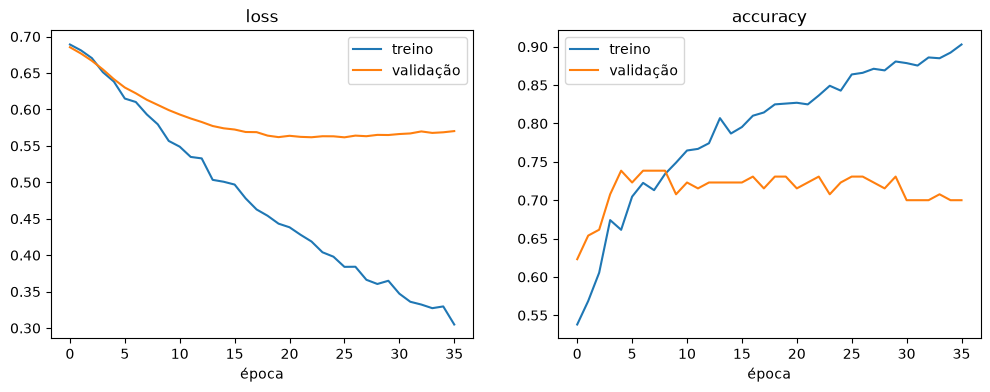

In [10]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
for eixo, metrica in zip(eixos, ["loss", "accuracy"]):
    eixo.plot(historico.history[metrica], label="treino")
    eixo.plot(historico.history[f"val_{metrica}"], label="validação")
    eixo.set_title(metrica)
    eixo.set_xlabel("época")
    eixo.legend()
plt.show()

## 7. Avaliação no conjunto de teste

Acurácia no teste: 69.67%

              precision    recall  f1-score   support

      normal       0.68      0.80      0.73        64
     anormal       0.72      0.59      0.65        58

    accuracy                           0.70       122
   macro avg       0.70      0.69      0.69       122
weighted avg       0.70      0.70      0.69       122



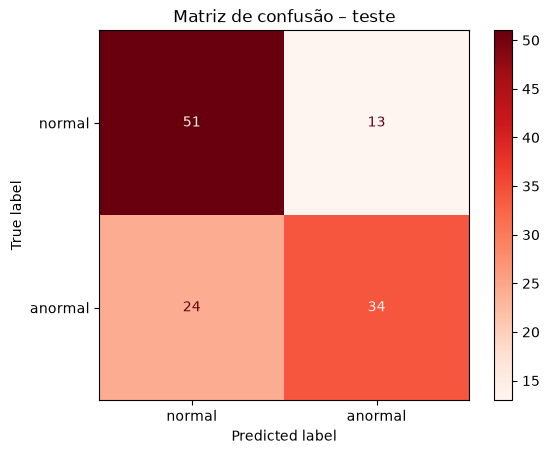

In [11]:
probabilidades = modelo.predict(X[teste], verbose=0).ravel()
previsoes = (probabilidades >= 0.5).astype(int)

print(f"Acurácia no teste: {accuracy_score(y[teste], previsoes):.2%}")
print()
print(classification_report(y[teste], previsoes, target_names=["normal", "anormal"]))

ConfusionMatrixDisplay.from_predictions(y[teste], previsoes, display_labels=["normal", "anormal"], cmap="Reds")
plt.title("Matriz de confusão – teste")
plt.show()

In [12]:
resultado_teste = amostra[teste].assign(previsto=np.where(previsoes, "anormal", "normal"))
anormais = resultado_teste[resultado_teste["classe"] == "anormal"].explode("superclasses")
anormais.groupby("superclasses").apply(lambda g: (g["previsto"] == "anormal").mean()).rename("acerto nos anormais").to_frame()

,acerto nos anormais
superclasses,
CD,0.629630
HYP,0.538462
MI,0.555556
STTC,0.608696


## 8. Análise dos resultados

**Desempenho geral.** A MLP acertou **69,7%** dos ECGs de teste: 122 exames de pacientes que a rede nunca viu. Um "modelo" que respondesse sempre "normal" acertaria 52%, então a rede aprendeu padrões reais do traçado. Mesmo assim, está longe de um uso clínico.

**O erro que importa.** O recall de **anormal** foi de **59%**: cerca de 4 em cada 10 ECGs alterados passariam como normais. Em triagem, esse falso negativo é o erro mais grave. Seria possível baixar o limiar de decisão (de 0,5 para 0,3, por exemplo) para pegar mais anormais, aceitando mais falsos alarmes.

**Acerto por tipo de alteração.** CD (distúrbio de condução) 63%, STTC (alteração ST/T) 61%, MI (infarto) 56% e HYP (hipertrofia) 54%. Os sinais de infarto e hipertrofia são detalhes pequenos (onda Q, supradesnível do ST, amplitude do QRS) em derivações específicas. Com 128 × 128 pixels, cada derivação fica com cerca de 10 pixels de altura, e parte desses detalhes se perde.

**Overfitting.** No fim do treino, a acurácia no treino passa de 85%, enquanto a validação fica em torno de 70%. A rede tem **4,2 milhões de parâmetros** para 948 imagens de treino e tende a decorar. Dropout, uma taxa de aprendizado baixa e o *early stopping* seguram o problema, mas não resolvem.

**Limite da MLP.** A MLP achata a imagem em um vetor e perde a noção de vizinhança entre pixels. Um mesmo batimento deslocado alguns pixels para o lado vira, para ela, uma entrada completamente diferente. Redes convolucionais (CNN) aprendem filtros locais que reconhecem um padrão em qualquer posição da imagem, e seriam o próximo passo natural. Para ECG, também daria para trabalhar direto com o sinal numérico, usando uma CNN 1D.

**Pré-processamento pesou mais que a rede.** Só trocar a escala automática por uma escala fixa (preservando a amplitude) subiu a acurácia de cerca de 65% para cerca de 71% (média de 5 execuções com a mesma rede e o mesmo treino). Ajustar camadas e neurônios quase não mudou o resultado. Na saúde, a forma como o dado é preparado importa tanto quanto o modelo.

**Viés nos dados.** O grupo anormal é **15 anos mais velho** (69 contra 54 anos em média) e tem **menos mulheres** (41% contra 53%). A rede pode estar aprendendo características de "ECG de pessoa idosa" em vez de "ECG alterado". Na prática, isso levaria a falsos alarmes em idosos saudáveis e a anormalidades não detectadas em pacientes jovens. Uma amostragem equilibrada por idade e sexo ajudaria a medir e reduzir esse efeito.

> Os resultados reforçam o papel da IA como **apoio** à triagem, nunca como substituta da leitura do ECG por um cardiologista.
